# 11 Pre-Writing Empirical Synthesis

This notebook consolidates final descriptive empirical outputs into thesis-ready tables, figures, and a short synthesis note.

Scope:
- descriptive event-window evidence,
- mechanism-oriented interpretation,
- cautious language (not definitive causal identification).


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 300)
pd.set_option('display.width', 240)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data'
PANEL_DIR = DATA_DIR / 'panel'
CORPUS_DIR = DATA_DIR / 'corpus'
INDICATORS_DIR = DATA_DIR / 'indicators'
DOCS_DIR = PROJECT_ROOT / 'docs'
FIGURES_DIR = PROJECT_ROOT / 'figures' / '11_notebook_figures'

DOCS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FULL_PANEL_TONE_PARQUET = PANEL_DIR / 'monthly_full_analysis_panel_with_tone_2013_2025.parquet'
FULL_PANEL_TONE_CSV = PANEL_DIR / 'monthly_full_analysis_panel_with_tone_2013_2025.csv'
FULL_PANEL_PARQUET = PANEL_DIR / 'monthly_full_analysis_panel_2013_2025.parquet'
FULL_PANEL_CSV = PANEL_DIR / 'monthly_full_analysis_panel_2013_2025.csv'

TEXT_SHOCK_SUMMARY_CSV = PANEL_DIR / 'full_panel_text_shock_window_summary.csv'
TONE_SHOCK_SUMMARY_CSV = PANEL_DIR / 'supplementary_tone_shock_window_summary.csv'
FINAL_DIAG_CSV = PANEL_DIR / 'final_descriptive_diagnostics.csv'

MASTER_PARQUET = CORPUS_DIR / 'master_articles.parquet'
MASTER_CSV = CORPUS_DIR / 'master_articles_light.csv'

MONTHLY_TEXT_PARQUET = INDICATORS_DIR / 'monthly_text_content_indicators.parquet'
MONTHLY_TEXT_CSV = INDICATORS_DIR / 'monthly_text_content_indicators.csv'
MONTHLY_TONE_PARQUET = INDICATORS_DIR / 'monthly_media_tone_indicators.parquet'
MONTHLY_TONE_CSV = INDICATORS_DIR / 'monthly_media_tone_indicators.csv'
ARTICLE_TEXT_PARQUET = INDICATORS_DIR / 'article_text_content_indicators.parquet'
ARTICLE_TEXT_CSV = INDICATORS_DIR / 'article_text_content_indicators.csv'
ARTICLE_TONE_PARQUET = INDICATORS_DIR / 'article_media_tone_indicators.parquet'
ARTICLE_TONE_CSV = INDICATORS_DIR / 'article_media_tone_indicators.csv'

OUT_SHOCK_TABLE_CSV = PANEL_DIR / 'thesis_master_shock_results_table.csv'
OUT_SHOCK_TABLE_PARQUET = PANEL_DIR / 'thesis_master_shock_results_table.parquet'
OUT_COUNTS_CSV = PANEL_DIR / 'thesis_dataset_counts_summary.csv'
OUT_SYNTH_NOTE_MD = DOCS_DIR / 'pre_writing_empirical_synthesis_note.md'

EXPECTED_RANGE = pd.period_range('2013-09', '2025-12', freq='M')
EXPECTED_ROWS = len(EXPECTED_RANGE)

SHOCKS = {
    'Cologne': pd.Timestamp('2016-01-01'),
    'Chemnitz': pd.Timestamp('2018-08-01'),
    'Correctiv': pd.Timestamp('2024-01-01'),
}

SHOCK_META = {
    'Cologne': {
        'shock_month': '2016-01',
        'expected_mechanism': 'Migration/security/public-order framing.',
        'expected_polling_direction': 'AfD support increases.',
    },
    'Chemnitz': {
        'shock_month': '2018-08',
        'expected_mechanism': 'Security/public-order and AfD/far-right framing.',
        'expected_polling_direction': 'Ambiguous / limited net national polling movement.',
    },
    'Correctiv': {
        'shock_month': '2024-01',
        'expected_mechanism': 'Remigration, democracy-threat, and AfD/far-right framing.',
        'expected_polling_direction': 'AfD support decreases.',
    },
}

REQUIRED_KEY_COLS = [
    'afd_poll_support_mean',
    'nexis_total_results',
    'migration_terms_per_1000_mean',
    'security_terms_per_1000_mean',
    'afd_far_right_terms_per_1000_mean',
    'remigration_democracy_terms_per_1000_mean',
    'negative_threat_terms_per_1000_mean',
]

OPTIONAL_TONE_COLS = [
    'tone_negative_terms_per_1000_mean',
    'tone_net_score_per_1000_mean',
    'share_articles_negative_tone',
]

warnings = []

print('Output files:')
print('shock table csv:', OUT_SHOCK_TABLE_CSV)
print('counts summary:', OUT_COUNTS_CSV)
print('synthesis note:', OUT_SYNTH_NOTE_MD)
print('figures dir:', FIGURES_DIR)


Output files:
shock table csv: c:\PythonProjects\AfD-project\data\panel\thesis_master_shock_results_table.csv
counts summary: c:\PythonProjects\AfD-project\data\panel\thesis_dataset_counts_summary.csv
synthesis note: c:\PythonProjects\AfD-project\docs\pre_writing_empirical_synthesis_note.md
figures dir: c:\PythonProjects\AfD-project\figures\11_notebook_figures


In [2]:
def load_table(parquet_path: Path, csv_path: Path, label: str, optional: bool = False):
    if parquet_path.exists():
        print(f'Loaded {label} from parquet: {parquet_path}')
        return pd.read_parquet(parquet_path)
    if csv_path.exists():
        print(f'Loaded {label} from csv: {csv_path}')
        return pd.read_csv(csv_path)
    if optional:
        warnings.append(f'Missing optional input: {label}')
        return None
    raise FileNotFoundError(f'Missing required input: {label} ({parquet_path} / {csv_path})')

# Prefer tone-augmented panel; fallback to non-tone panel.
panel_source = None
if FULL_PANEL_TONE_PARQUET.exists() or FULL_PANEL_TONE_CSV.exists():
    panel = load_table(FULL_PANEL_TONE_PARQUET, FULL_PANEL_TONE_CSV, 'full panel with tone')
    panel_source = 'with_tone'
else:
    panel = load_table(FULL_PANEL_PARQUET, FULL_PANEL_CSV, 'full panel (no tone fallback)')
    panel_source = 'no_tone_fallback'

panel = panel.copy()
panel['year_month'] = panel['year_month'].astype(str)
panel['month_dt'] = pd.to_datetime(panel['year_month'] + '-01', errors='coerce')
if panel['month_dt'].isna().any():
    bad = panel.loc[panel['month_dt'].isna(), 'year_month'].head(10).tolist()
    raise ValueError(f'Unparseable year_month values in panel: {bad}')

if len(panel) != EXPECTED_ROWS:
    raise ValueError(f'Panel row mismatch: got {len(panel)} expected {EXPECTED_ROWS}')
if panel['year_month'].duplicated().any():
    dupes = panel.loc[panel['year_month'].duplicated(), 'year_month'].head(10).tolist()
    raise ValueError(f'Panel has duplicate months: {dupes}')

periods = pd.PeriodIndex(panel['year_month'], freq='M')
missing = EXPECTED_RANGE.difference(periods)
extra = periods.difference(EXPECTED_RANGE)
if len(missing) > 0 or len(extra) > 0:
    raise ValueError(
        'Panel coverage mismatch. '
        f'missing={ [p.strftime("%Y-%m") for p in missing] }, '
        f'extra={ [p.strftime("%Y-%m") for p in extra] }'
    )

missing_required_cols = [c for c in REQUIRED_KEY_COLS if c not in panel.columns]
if missing_required_cols:
    raise ValueError(f'Panel missing required key columns: {missing_required_cols}')

missing_required_vals = {c: int(panel[c].isna().sum()) for c in REQUIRED_KEY_COLS}
if any(v > 0 for v in missing_required_vals.values()):
    raise ValueError(f'Panel has missing values in required key columns: {missing_required_vals}')

tone_available = all(c in panel.columns for c in OPTIONAL_TONE_COLS)
if tone_available:
    missing_tone_vals = {c: int(panel[c].isna().sum()) for c in OPTIONAL_TONE_COLS}
    if any(v > 0 for v in missing_tone_vals.values()):
        raise ValueError(f'Panel has missing values in tone columns: {missing_tone_vals}')
else:
    warnings.append('Tone columns unavailable in selected final panel; tone fields in outputs will be NaN where needed.')

panel = panel.sort_values('month_dt').reset_index(drop=True)

print('Panel validation complete:')
print('panel_source:', panel_source)
print('rows:', len(panel))
print('coverage:', panel['year_month'].min(), 'to', panel['year_month'].max())
print('missing required values:', missing_required_vals)
print('tone_available:', tone_available)


Loaded full panel with tone from parquet: c:\PythonProjects\AfD-project\data\panel\monthly_full_analysis_panel_with_tone_2013_2025.parquet
Panel validation complete:
panel_source: with_tone
rows: 148
coverage: 2013-09 to 2025-12
missing required values: {'afd_poll_support_mean': 0, 'nexis_total_results': 0, 'migration_terms_per_1000_mean': 0, 'security_terms_per_1000_mean': 0, 'afd_far_right_terms_per_1000_mean': 0, 'remigration_democracy_terms_per_1000_mean': 0, 'negative_threat_terms_per_1000_mean': 0}
tone_available: True


In [3]:
master = load_table(MASTER_PARQUET, MASTER_CSV, 'master corpus')
article_text = load_table(ARTICLE_TEXT_PARQUET, ARTICLE_TEXT_CSV, 'article text indicators', optional=True)
article_tone = load_table(ARTICLE_TONE_PARQUET, ARTICLE_TONE_CSV, 'article tone indicators', optional=True)
monthly_text = load_table(MONTHLY_TEXT_PARQUET, MONTHLY_TEXT_CSV, 'monthly text indicators', optional=True)
monthly_tone = load_table(MONTHLY_TONE_PARQUET, MONTHLY_TONE_CSV, 'monthly tone indicators', optional=True)

master_total_rows = len(master)
if 'keep_drop_review' in master.columns:
    status = master['keep_drop_review'].astype(str).str.lower()
    master_kept_rows = int((status == 'keep').sum())
    master_dropped_rows = int((status == 'drop').sum())
else:
    master_kept_rows = np.nan
    master_dropped_rows = np.nan
    warnings.append('master keep/drop counts unavailable: keep_drop_review column missing')

counts = {
    'master_articles_total_rows': master_total_rows,
    'master_articles_kept_rows': master_kept_rows,
    'master_articles_dropped_rows': master_dropped_rows,
    'article_text_indicator_rows': int(len(article_text)) if article_text is not None else np.nan,
    'article_tone_indicator_rows': int(len(article_tone)) if article_tone is not None else np.nan,
    'monthly_text_indicator_rows': int(len(monthly_text)) if monthly_text is not None else np.nan,
    'monthly_tone_indicator_rows': int(len(monthly_tone)) if monthly_tone is not None else np.nan,
    'final_panel_rows': int(len(panel)),
    'final_panel_start': panel['year_month'].min(),
    'final_panel_end': panel['year_month'].max(),
    'number_of_shocks': int(len(SHOCKS)),
}

if 'polling_source_block' in panel.columns:
    for k, v in panel['polling_source_block'].value_counts().to_dict().items():
        safe = str(k).lower().replace(' ', '_').replace('-', '_')
        counts[f'polling_source_block_count_{safe}'] = int(v)
else:
    warnings.append('polling_source_block missing in final panel; source-block counts omitted.')

counts_df = pd.DataFrame([counts])
counts_df.to_csv(OUT_COUNTS_CSV, index=False)

print('Saved dataset counts summary:', OUT_COUNTS_CSV)
print(counts_df.to_string(index=False))


Loaded master corpus from parquet: c:\PythonProjects\AfD-project\data\corpus\master_articles.parquet
Loaded article text indicators from parquet: c:\PythonProjects\AfD-project\data\indicators\article_text_content_indicators.parquet
Loaded article tone indicators from parquet: c:\PythonProjects\AfD-project\data\indicators\article_media_tone_indicators.parquet
Loaded monthly text indicators from parquet: c:\PythonProjects\AfD-project\data\indicators\monthly_text_content_indicators.parquet
Loaded monthly tone indicators from parquet: c:\PythonProjects\AfD-project\data\indicators\monthly_media_tone_indicators.parquet
Saved dataset counts summary: c:\PythonProjects\AfD-project\data\panel\thesis_dataset_counts_summary.csv
 master_articles_total_rows  master_articles_kept_rows  master_articles_dropped_rows  article_text_indicator_rows  article_tone_indicator_rows  monthly_text_indicator_rows  monthly_tone_indicator_rows  final_panel_rows final_panel_start final_panel_end  number_of_shocks  po

In [4]:
# Optional precomputed summaries for cross-checking only.
text_shock = pd.read_csv(TEXT_SHOCK_SUMMARY_CSV) if TEXT_SHOCK_SUMMARY_CSV.exists() else None
if text_shock is None:
    warnings.append('Missing optional text shock summary file: full_panel_text_shock_window_summary.csv')

tone_shock = pd.read_csv(TONE_SHOCK_SUMMARY_CSV) if TONE_SHOCK_SUMMARY_CSV.exists() else None
if tone_shock is None:
    warnings.append('Missing optional tone shock summary file: supplementary_tone_shock_window_summary.csv')

final_diag = pd.read_csv(FINAL_DIAG_CSV) if FINAL_DIAG_CSV.exists() else None
if final_diag is None:
    warnings.append('Missing optional final diagnostics file: final_descriptive_diagnostics.csv')

text_var_col = None
if text_shock is not None:
    if 'variable' in text_shock.columns:
        text_var_col = 'variable'
    elif 'indicator' in text_shock.columns:
        text_var_col = 'indicator'
    else:
        warnings.append('Text shock summary missing both variable/indicator columns; direct panel fallback will be used.')


def window_change_direct(df: pd.DataFrame, shock_dt: pd.Timestamp, var: str, win: int):
    if var not in df.columns:
        return np.nan
    w = df[(df['month_dt'] >= shock_dt - pd.DateOffset(months=win)) & (df['month_dt'] <= shock_dt + pd.DateOffset(months=win))].copy()
    w['rel_month'] = ((w['month_dt'].dt.year - shock_dt.year) * 12 + (w['month_dt'].dt.month - shock_dt.month)).astype(int)
    pre = w[w['rel_month'] < 0][var]
    post = w[w['rel_month'] > 0][var]
    if len(pre) == 0 or len(post) == 0:
        return np.nan
    return float(post.mean() - pre.mean())


def get_change(shock_label: str, var: str, win: int):
    dt = SHOCKS[shock_label]

    if tone_shock is not None:
        sub = tone_shock[
            (tone_shock['shock_label'] == shock_label)
            & (tone_shock['variable'] == var)
            & (tone_shock['window_months'] == win)
        ]
        if len(sub) == 1 and pd.notna(sub['change_post_minus_pre'].iloc[0]):
            return float(sub['change_post_minus_pre'].iloc[0])

    if text_shock is not None and text_var_col is not None:
        sub = text_shock[
            (text_shock['shock_label'] == shock_label)
            & (text_shock[text_var_col].fillna('') == var)
            & (text_shock['window_months'] == win)
        ]
        if len(sub) == 1 and pd.notna(sub['change_post_minus_pre'].iloc[0]):
            return float(sub['change_post_minus_pre'].iloc[0])

    return window_change_direct(panel, dt, var, win)


def interpret_row(shock: str, row: dict):
    afd6 = row['afd_polling_change_pm6m']
    sec6 = row['security_change_pm6m']
    far6 = row['afd_far_right_change_pm6m']
    rem6 = row['remigration_democracy_change_pm6m']
    tone_neg6 = row['tone_negative_change_pm6m']
    tone_net6 = row['tone_net_change_pm6m']

    if shock == 'Cologne':
        if afd6 > 0 and sec6 > 0:
            main = 'Pattern-consistent: polling increase with stronger security/public-order framing.'
        else:
            main = 'Mixed evidence relative to expected Cologne mechanism.'

        if pd.notna(tone_neg6):
            if tone_neg6 > 0:
                tone = 'Tone is broadly aligned with a more negative evaluative environment.'
            else:
                tone = 'Tone qualifies the mechanism: the case is better interpreted as security/public-order framing rather than generic negativity.'
        else:
            tone = 'Tone not available in final panel.'

    elif shock == 'Chemnitz':
        if sec6 > 0 and far6 > 0 and abs(afd6) <= 1.0:
            main = 'Pattern-consistent as a framing shock with limited net national polling movement.'
        elif sec6 > 0 and far6 > 0:
            main = 'Framing indicators rise, but polling movement is not limited.'
        else:
            main = 'Mixed evidence relative to expected Chemnitz framing mechanism.'

        if pd.notna(tone_neg6):
            if tone_neg6 > 0:
                tone = 'Tone broadly aligns with heightened negativity in the shock window.'
            else:
                tone = 'Tone qualifies the interpretation: framing moves more clearly than general negative tone.'
        else:
            tone = 'Tone not available in final panel.'

    else:  # Correctiv
        if afd6 < 0 and rem6 > 0 and far6 > 0:
            main = 'Pattern-consistent: polling decline with remigration/democracy-threat and AfD/far-right content surge.'
        else:
            main = 'Mixed evidence relative to expected Correctiv mechanism.'

        if pd.notna(tone_neg6) and pd.notna(tone_net6):
            if tone_neg6 > 0 or tone_net6 < 0:
                tone = 'Tone reinforces the interpretation.'
            else:
                tone = 'Tone is mixed and partially qualifies the interpretation.'
        else:
            tone = 'Tone not available in final panel.'

    final_interp = f'{main} {tone}'
    causal_note = 'Descriptive event-window evidence; consistent with the proposed mechanism, not definitive causal identification.'
    return main, tone, final_interp, causal_note

rows = []
for shock in ['Cologne', 'Chemnitz', 'Correctiv']:
    meta = SHOCK_META[shock]
    row = {
        'shock_label': shock,
        'shock_month': meta['shock_month'],
        'expected_mechanism': meta['expected_mechanism'],
        'expected_polling_direction': meta['expected_polling_direction'],
        'afd_polling_change_pm3m': get_change(shock, 'afd_poll_support_mean', 3),
        'afd_polling_change_pm6m': get_change(shock, 'afd_poll_support_mean', 6),
        'nexis_salience_change_pm3m': get_change(shock, 'nexis_total_results', 3),
        'nexis_salience_change_pm6m': get_change(shock, 'nexis_total_results', 6),
        'migration_change_pm3m': get_change(shock, 'migration_terms_per_1000_mean', 3),
        'migration_change_pm6m': get_change(shock, 'migration_terms_per_1000_mean', 6),
        'security_change_pm3m': get_change(shock, 'security_terms_per_1000_mean', 3),
        'security_change_pm6m': get_change(shock, 'security_terms_per_1000_mean', 6),
        'afd_far_right_change_pm3m': get_change(shock, 'afd_far_right_terms_per_1000_mean', 3),
        'afd_far_right_change_pm6m': get_change(shock, 'afd_far_right_terms_per_1000_mean', 6),
        'remigration_democracy_change_pm3m': get_change(shock, 'remigration_democracy_terms_per_1000_mean', 3),
        'remigration_democracy_change_pm6m': get_change(shock, 'remigration_democracy_terms_per_1000_mean', 6),
        'negative_threat_change_pm3m': get_change(shock, 'negative_threat_terms_per_1000_mean', 3),
        'negative_threat_change_pm6m': get_change(shock, 'negative_threat_terms_per_1000_mean', 6),
    }

    if tone_available:
        row['tone_negative_change_pm3m'] = get_change(shock, 'tone_negative_terms_per_1000_mean', 3)
        row['tone_negative_change_pm6m'] = get_change(shock, 'tone_negative_terms_per_1000_mean', 6)
        row['tone_net_change_pm3m'] = get_change(shock, 'tone_net_score_per_1000_mean', 3)
        row['tone_net_change_pm6m'] = get_change(shock, 'tone_net_score_per_1000_mean', 6)
    else:
        row['tone_negative_change_pm3m'] = np.nan
        row['tone_negative_change_pm6m'] = np.nan
        row['tone_net_change_pm3m'] = np.nan
        row['tone_net_change_pm6m'] = np.nan

    main, tone, final_interp, causal = interpret_row(shock, row)
    row['main_empirical_pattern'] = main
    row['tone_interpretation'] = tone
    row['final_interpretation'] = final_interp
    row['causal_language_note'] = causal

    rows.append(row)

shock_table = pd.DataFrame(rows)
shock_table.to_csv(OUT_SHOCK_TABLE_CSV, index=False)
shock_table.to_parquet(OUT_SHOCK_TABLE_PARQUET, index=False)

print('Saved shock table CSV:', OUT_SHOCK_TABLE_CSV)
print('Saved shock table parquet:', OUT_SHOCK_TABLE_PARQUET)
print(shock_table.to_string(index=False))



Saved shock table CSV: c:\PythonProjects\AfD-project\data\panel\thesis_master_shock_results_table.csv
Saved shock table parquet: c:\PythonProjects\AfD-project\data\panel\thesis_master_shock_results_table.parquet
shock_label shock_month                                        expected_mechanism                         expected_polling_direction  afd_polling_change_pm3m  afd_polling_change_pm6m  nexis_salience_change_pm3m  nexis_salience_change_pm6m  migration_change_pm3m  migration_change_pm6m  security_change_pm3m  security_change_pm6m  afd_far_right_change_pm3m  afd_far_right_change_pm6m  remigration_democracy_change_pm3m  remigration_democracy_change_pm6m  negative_threat_change_pm3m  negative_threat_change_pm6m  tone_negative_change_pm3m  tone_negative_change_pm6m  tone_net_change_pm3m  tone_net_change_pm6m                                                                                 main_empirical_pattern                                                                             

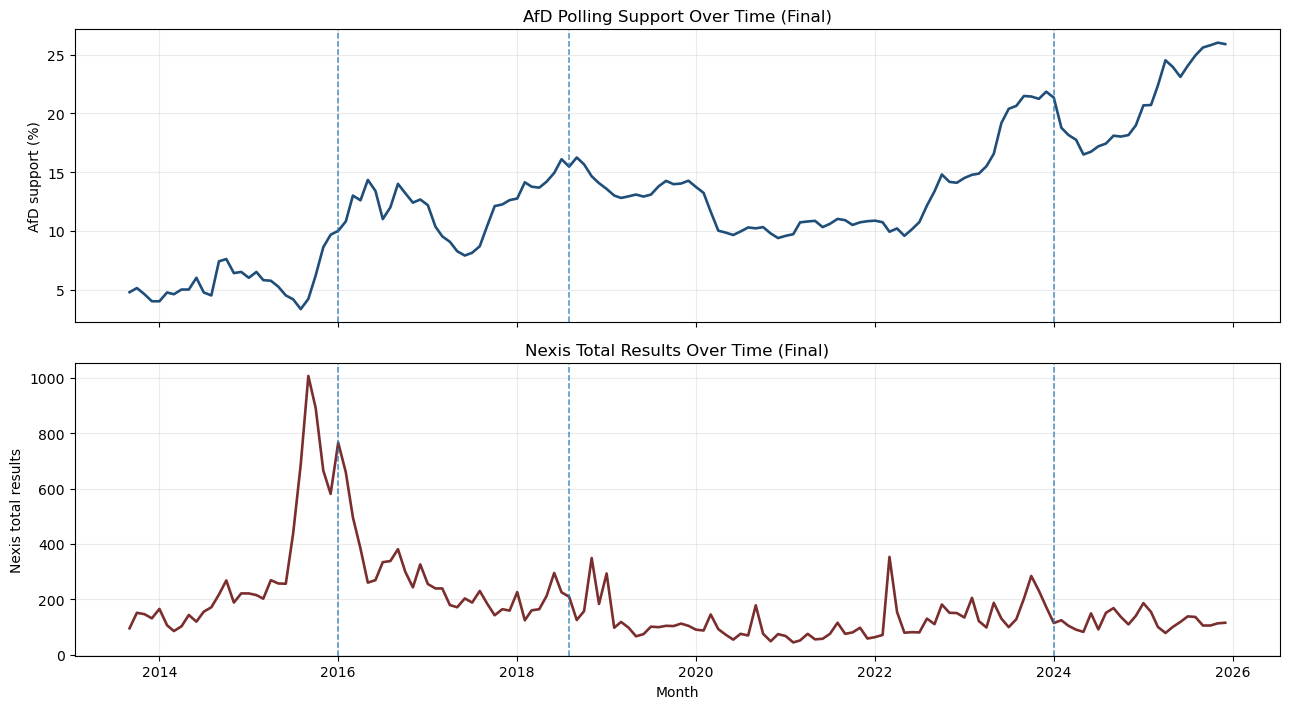

Saved: c:\PythonProjects\AfD-project\figures\11_notebook_figures\overview_afd_support_and_nexis_volume_final.png


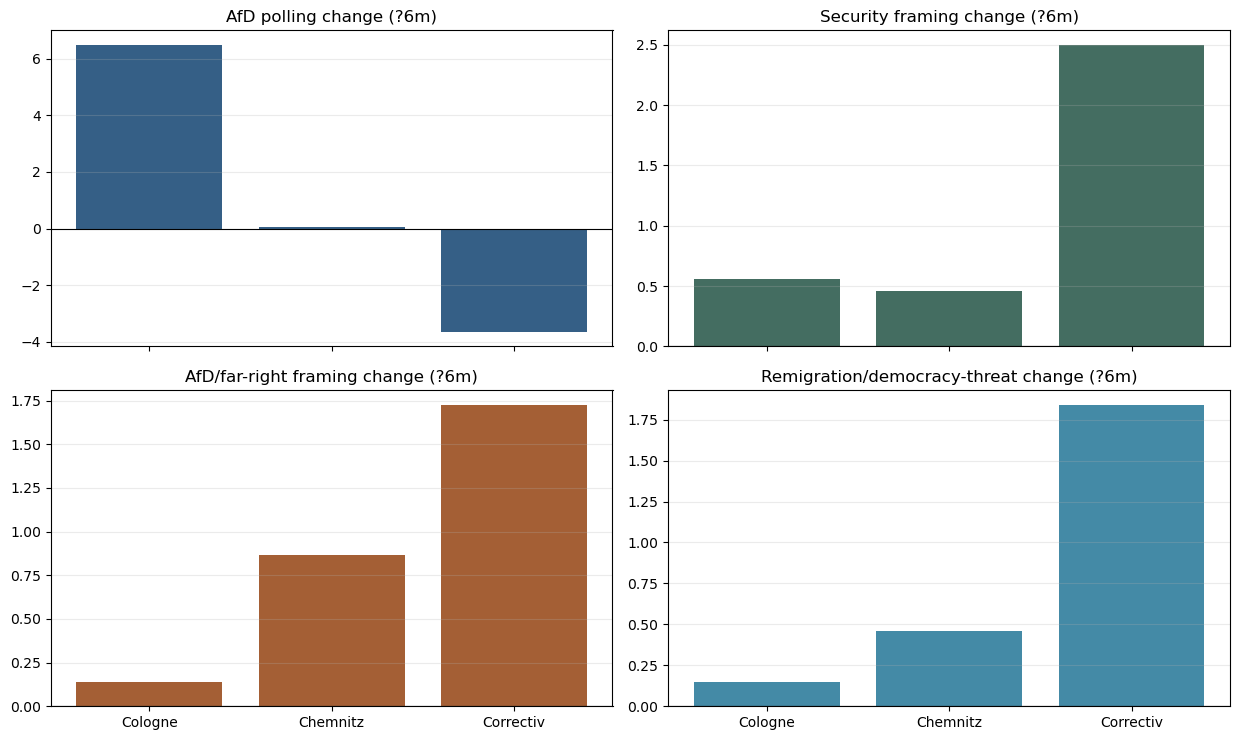

Saved: c:\PythonProjects\AfD-project\figures\11_notebook_figures\shock_results_bar_pm6m_final.png


In [5]:
def add_shock_lines(ax):
    for label, dt in SHOCKS.items():
        ax.axvline(dt, linestyle='--', linewidth=1.1, alpha=0.8)

# A) Final overview figure (stacked panels)
fig, axes = plt.subplots(2, 1, figsize=(13, 7.2), sharex=True)

axes[0].plot(panel['month_dt'], panel['afd_poll_support_mean'], color='#1f4e79', linewidth=1.9)
axes[0].set_title('AfD Polling Support Over Time (Final)')
axes[0].set_ylabel('AfD support (%)')
axes[0].grid(alpha=0.25)
add_shock_lines(axes[0])

axes[1].plot(panel['month_dt'], panel['nexis_total_results'], color='#7a2e2e', linewidth=1.9)
axes[1].set_title('Nexis Total Results Over Time (Final)')
axes[1].set_ylabel('Nexis total results')
axes[1].set_xlabel('Month')
axes[1].grid(alpha=0.25)
add_shock_lines(axes[1])

fig.tight_layout()
out_overview = FIGURES_DIR / 'overview_afd_support_and_nexis_volume_final.png'
fig.savefig(out_overview, dpi=160)
plt.show()
print('Saved:', out_overview)

# B) +/-6m change comparison (separate readable panels)
bar_vars = [
    ('afd_polling_change_pm6m', 'AfD polling change (?6m)', '#1f4e79'),
    ('security_change_pm6m', 'Security framing change (?6m)', '#2f5d50'),
    ('afd_far_right_change_pm6m', 'AfD/far-right framing change (?6m)', '#9a4d1f'),
    ('remigration_democracy_change_pm6m', 'Remigration/democracy-threat change (?6m)', '#2f7d9d'),
]

fig, axes = plt.subplots(2, 2, figsize=(12.5, 7.5), sharex=True)
axes = axes.flatten()
for ax, (var, title, color) in zip(axes, bar_vars):
    vals = shock_table.set_index('shock_label').loc[['Cologne', 'Chemnitz', 'Correctiv'], var]
    ax.bar(vals.index, vals.values, color=color, alpha=0.9)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.25)

fig.tight_layout()
out_bars = FIGURES_DIR / 'shock_results_bar_pm6m_final.png'
fig.savefig(out_bars, dpi=160)
plt.show()
print('Saved:', out_bars)


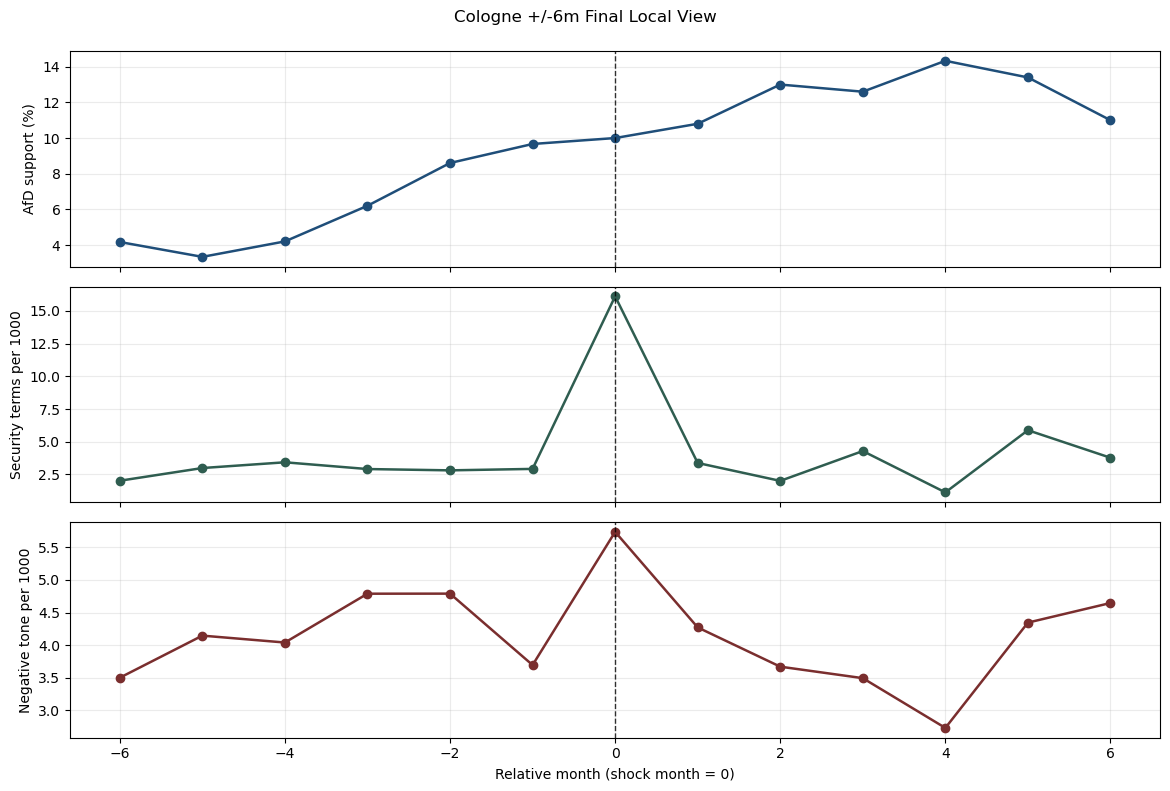

Saved: c:\PythonProjects\AfD-project\figures\11_notebook_figures\cologne_local_window_pm6m_final.png


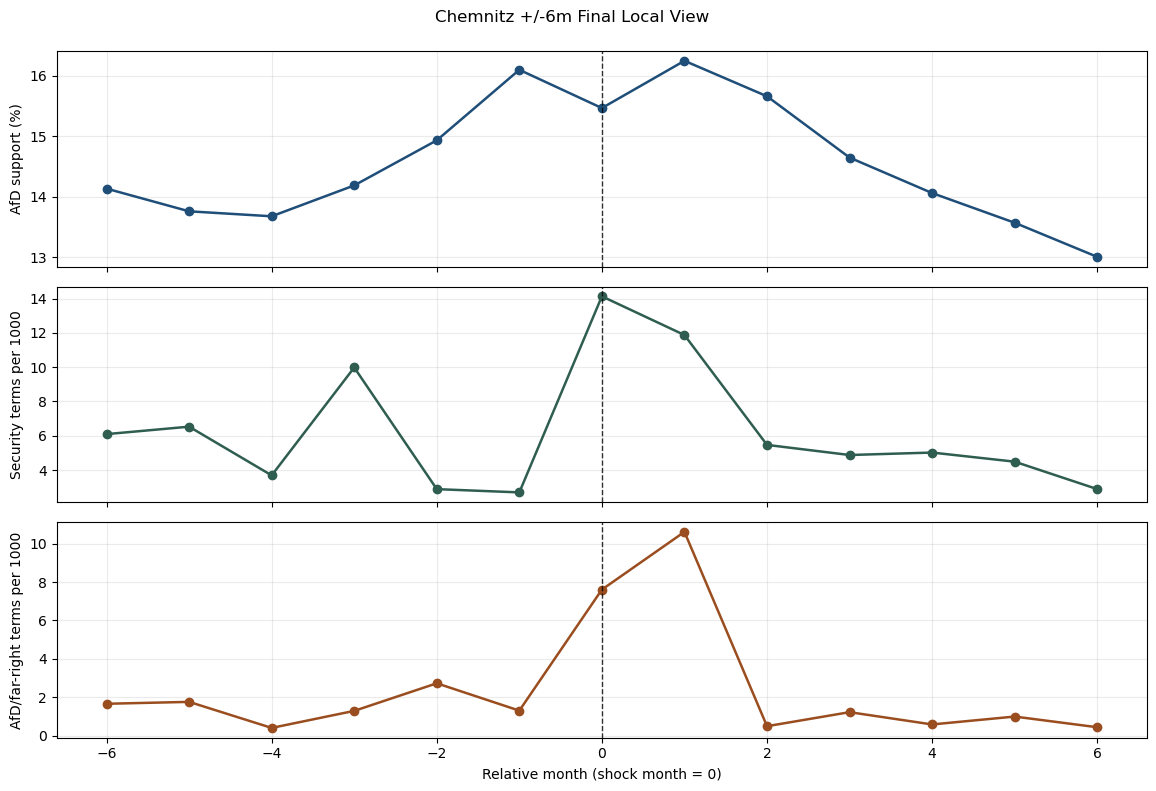

Saved: c:\PythonProjects\AfD-project\figures\11_notebook_figures\chemnitz_local_window_pm6m_final.png


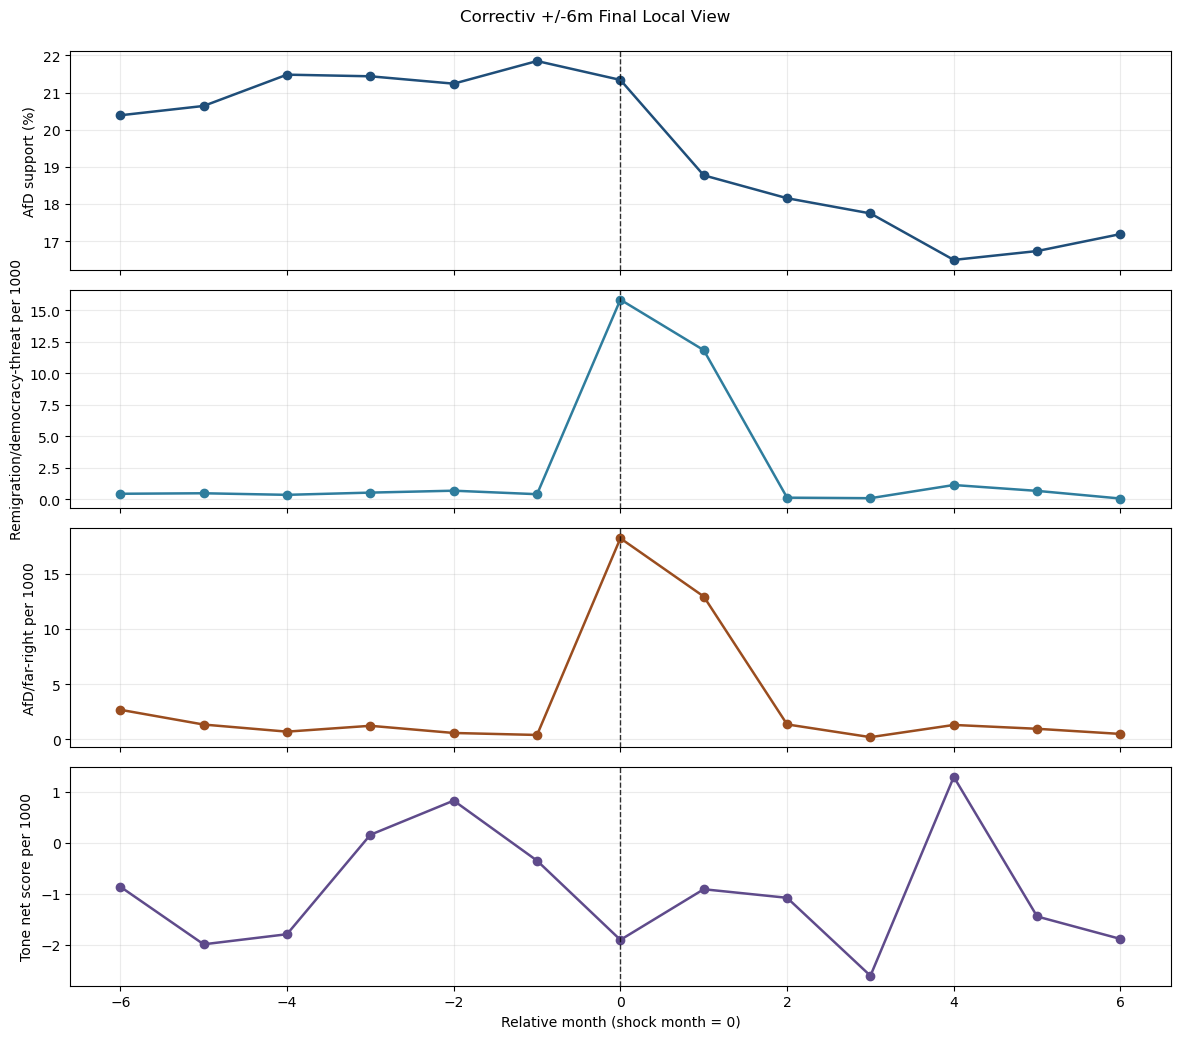

Saved: c:\PythonProjects\AfD-project\figures\11_notebook_figures\correctiv_local_window_pm6m_final.png


In [6]:
def local_window(df: pd.DataFrame, shock_month: pd.Timestamp, win: int = 6) -> pd.DataFrame:
    w = df[(df['month_dt'] >= shock_month - pd.DateOffset(months=win)) & (df['month_dt'] <= shock_month + pd.DateOffset(months=win))].copy()
    w['rel_month'] = ((w['month_dt'].dt.year - shock_month.year) * 12 + (w['month_dt'].dt.month - shock_month.month)).astype(int)
    return w.sort_values('rel_month').reset_index(drop=True)


def plot_local_stacked(w: pd.DataFrame, specs: list[tuple[str, str, str]], title: str, out_path: Path):
    n = len(specs)
    fig, axes = plt.subplots(n, 1, figsize=(11.8, 2.5 * n + 0.4), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, (col, ylab, color) in zip(axes, specs):
        if col not in w.columns:
            ax.text(0.5, 0.5, f'Missing: {col}', transform=ax.transAxes, ha='center', va='center')
            ax.set_ylabel(ylab)
            continue
        ax.plot(w['rel_month'], pd.to_numeric(w[col], errors='coerce'), marker='o', linewidth=1.8, color=color)
        ax.axvline(0, linestyle='--', linewidth=1.0, color='black', alpha=0.8)
        ax.set_ylabel(ylab)
        ax.grid(alpha=0.25)

    axes[-1].set_xlabel('Relative month (shock month = 0)')
    fig.suptitle(title, y=0.995)
    fig.tight_layout()
    fig.savefig(out_path, dpi=160)
    plt.show()
    print('Saved:', out_path)

w_cologne = local_window(panel, SHOCKS['Cologne'], win=6)
cols_cologne = [
    ('afd_poll_support_mean', 'AfD support (%)', '#1f4e79'),
    ('security_terms_per_1000_mean', 'Security terms per 1000', '#2f5d50'),
]
if 'tone_negative_terms_per_1000_mean' in panel.columns:
    cols_cologne.append(('tone_negative_terms_per_1000_mean', 'Negative tone per 1000', '#7a2e2e'))
else:
    cols_cologne.append(('nexis_total_results', 'Nexis total results', '#7a2e2e'))
plot_local_stacked(
    w_cologne,
    cols_cologne,
    'Cologne +/-6m Final Local View',
    FIGURES_DIR / 'cologne_local_window_pm6m_final.png'
)

w_chemnitz = local_window(panel, SHOCKS['Chemnitz'], win=6)
plot_local_stacked(
    w_chemnitz,
    [
        ('afd_poll_support_mean', 'AfD support (%)', '#1f4e79'),
        ('security_terms_per_1000_mean', 'Security terms per 1000', '#2f5d50'),
        ('afd_far_right_terms_per_1000_mean', 'AfD/far-right terms per 1000', '#9a4d1f'),
    ],
    'Chemnitz +/-6m Final Local View',
    FIGURES_DIR / 'chemnitz_local_window_pm6m_final.png'
)

w_correctiv = local_window(panel, SHOCKS['Correctiv'], win=6)
cols_correctiv = [
    ('afd_poll_support_mean', 'AfD support (%)', '#1f4e79'),
    ('remigration_democracy_terms_per_1000_mean', 'Remigration/democracy-threat per 1000', '#2f7d9d'),
    ('afd_far_right_terms_per_1000_mean', 'AfD/far-right per 1000', '#9a4d1f'),
]
if 'tone_net_score_per_1000_mean' in panel.columns:
    cols_correctiv.append(('tone_net_score_per_1000_mean', 'Tone net score per 1000', '#5f4b8b'))
plot_local_stacked(
    w_correctiv,
    cols_correctiv,
    'Correctiv +/-6m Final Local View',
    FIGURES_DIR / 'correctiv_local_window_pm6m_final.png'
)


In [7]:
def f2(x):
    return 'n/a' if pd.isna(x) else f'{x:.2f}'

rows_txt = []
for _, r in shock_table.iterrows():
    rows_txt.append(
        f"- **{r['shock_label']} ({r['shock_month']})**: {r['final_interpretation']} "
        f"(AfD +/-6={f2(r['afd_polling_change_pm6m'])}; Security +/-6={f2(r['security_change_pm6m'])}; "
        f"AfD/far-right +/-6={f2(r['afd_far_right_change_pm6m'])}; Remigration/democracy +/-6={f2(r['remigration_democracy_change_pm6m'])})."
    )

note_lines = [
    '# Pre-Writing Empirical Synthesis Note',
    '',
    'Last updated: 2026-05-13',
    '',
    '## Final Project Framing',
    'This thesis uses text-based media salience and framing indicators to assess how AfD-relevant political-media shocks are reflected in German news coverage and how these patterns align with AfD polling support. Evidence is interpreted descriptively in event-window form and in mechanism-oriented terms.',
    '',
    '## Final Data Basis',
    f"The final monthly panel contains {len(panel)} rows covering {panel['year_month'].min()} to {panel['year_month'].max()}.",
    'Key variables include AfD polling support, Nexis volume salience, migration/security/AfD-far-right/remigration-democracy-threat/negative-threat framing indicators, and supplementary tone metrics when available.',
    '',
    '## Indicator Layer Distinction',
    '- **Salience**: volume of attention in monthly Nexis counts.',
    '- **Framing/content indicators**: dictionary-based issue/mechanism emphasis measures.',
    '- **Supplementary tone proxy**: lexicon-based evaluative tone diagnostic; supplementary and not a replacement for salience/framing.',
    '',
    '## Shock-by-Shock Descriptive Synthesis',
]
note_lines.extend(rows_txt)
note_lines.extend([
    '',
    '## Limitations',
    'Findings are descriptive event-window summaries and mechanism-oriented interpretations. They are aligned with the proposed mechanisms where patterns match, but they are not definitive causal identification. The supplementary tone proxy is transparent and useful diagnostically, but it is not a target-specific sentiment classifier.',
])

OUT_SYNTH_NOTE_MD.write_text('\n'.join(note_lines), encoding='utf-8')
print('Saved synthesis note:', OUT_SYNTH_NOTE_MD)
print('\n'.join(note_lines[:24]))



Saved synthesis note: c:\PythonProjects\AfD-project\docs\pre_writing_empirical_synthesis_note.md
# Pre-Writing Empirical Synthesis Note

Last updated: 2026-05-13

## Final Project Framing
This thesis uses text-based media salience and framing indicators to assess how AfD-relevant political-media shocks are reflected in German news coverage and how these patterns align with AfD polling support. Evidence is interpreted descriptively in event-window form and in mechanism-oriented terms.

## Final Data Basis
The final monthly panel contains 148 rows covering 2013-09 to 2025-12.
Key variables include AfD polling support, Nexis volume salience, migration/security/AfD-far-right/remigration-democracy-threat/negative-threat framing indicators, and supplementary tone metrics when available.

## Indicator Layer Distinction
- **Salience**: volume of attention in monthly Nexis counts.
- **Framing/content indicators**: dictionary-based issue/mechanism emphasis measures.
- **Supplementary tone proxy*

In [8]:
figure_paths = [
    FIGURES_DIR / 'overview_afd_support_and_nexis_volume_final.png',
    FIGURES_DIR / 'shock_results_bar_pm6m_final.png',
    FIGURES_DIR / 'cologne_local_window_pm6m_final.png',
    FIGURES_DIR / 'chemnitz_local_window_pm6m_final.png',
    FIGURES_DIR / 'correctiv_local_window_pm6m_final.png',
]

print('Final checkpoint:')
print('final panel rows:', len(panel))
print('final panel coverage:', panel['year_month'].min(), 'to', panel['year_month'].max())
print('tone fields available:', tone_available)
print('shock table path:', OUT_SHOCK_TABLE_CSV, 'exists=', OUT_SHOCK_TABLE_CSV.exists())
print('dataset counts summary path:', OUT_COUNTS_CSV, 'exists=', OUT_COUNTS_CSV.exists())
print('synthesis note path:', OUT_SYNTH_NOTE_MD, 'exists=', OUT_SYNTH_NOTE_MD.exists())
print('generated figure paths:')
for p in figure_paths:
    print('-', p, 'exists=', p.exists())

if warnings:
    print('warnings:')
    for w in warnings:
        print('-', w)
else:
    print('warnings: none')


Final checkpoint:
final panel rows: 148
final panel coverage: 2013-09 to 2025-12
tone fields available: True
shock table path: c:\PythonProjects\AfD-project\data\panel\thesis_master_shock_results_table.csv exists= True
dataset counts summary path: c:\PythonProjects\AfD-project\data\panel\thesis_dataset_counts_summary.csv exists= True
synthesis note path: c:\PythonProjects\AfD-project\docs\pre_writing_empirical_synthesis_note.md exists= True
generated figure paths:
- c:\PythonProjects\AfD-project\figures\11_notebook_figures\overview_afd_support_and_nexis_volume_final.png exists= True
- c:\PythonProjects\AfD-project\figures\11_notebook_figures\shock_results_bar_pm6m_final.png exists= True
- c:\PythonProjects\AfD-project\figures\11_notebook_figures\cologne_local_window_pm6m_final.png exists= True
- c:\PythonProjects\AfD-project\figures\11_notebook_figures\chemnitz_local_window_pm6m_final.png exists= True
- c:\PythonProjects\AfD-project\figures\11_notebook_figures\correctiv_local_window_pm